In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries imported ✅")

Libraries imported ✅


In [3]:
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Shape:", df.shape)
print("Date Range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
df.head()

Shape: (776577, 15)
Date Range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday,4


# RFM Analysis

RFM stands for:
- Recency   → How RECENTLY did the customer buy? (days since last purchase)
- Frequency → How OFTEN do they buy? (number of orders)
- Monetary  → How MUCH do they spend? (total revenue)

A customer who bought YESTERDAY, buys EVERY WEEK, and spends £1000
is WAY more valuable than someone who bought 6 months ago, once, for £10.

RFM helps us segment customers into groups and treat them differently.

In [4]:
# Snapshot date = 1 day after last transaction
# This is the "today" for our analysis

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [5]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("RFM Table Shape:", rfm.shape)
print("\nSample RFM:")
rfm.head(10)

RFM Table Shape: (5852, 4)

Sample RFM:


,Customer ID,Recency,Frequency,Monetary
0,12346,326,3,77352.96
1,12347,2,8,4921.53
2,12348,75,5,1658.40
3,12349,19,3,3678.69
4,12350,310,1,294.40
5,12351,375,1,300.93
6,12352,36,9,1729.54
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [6]:
print("📊 RFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

📊 RFM Statistics:
       Recency  Frequency   Monetary
count  5852.00    5852.00    5852.00
mean    200.20       6.25    2916.71
std     208.51      12.75   14306.85
min       1.00       1.00       2.95
25%      25.00       1.00     339.58
50%      95.00       3.00     856.02
75%     379.00       7.00    2241.03
max     739.00     373.00  580987.04


In [7]:
# Recency → lower is better (bought recently = good)
# Frequency → higher is better
# Monetary → higher is better

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Convert to int
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Total RFM Score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("Scores added ✅")
print(rfm[['Customer ID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

Scores added ✅
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326          3  77352.96        2        2        4   
1        12347        2          8   4921.53        4        4        4   
2        12348       75          5   1658.40        3        3        3   
3        12349       19          3   3678.69        4        2        4   
4        12350      310          1    294.40        2        1        1   
5        12351      375          1    300.93        2        1        1   
6        12352       36          9   1729.54        3        4        3   
7        12353      204          2    406.76        2        2        2   
8        12354      232          1   1079.40        2        1        3   
9        12355      214          2    947.61        2        2        3   

   RFM_Score  
0          8  
1         12  
2          9  
3         10  
4          4  
5          4  
6         10  
7          6  
8          6  
9        

In [8]:
def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print("Segments created ✅")
print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

Segments created ✅

Segment Distribution:
Segment
Champions              1721
Potential Loyalists    1220
Loyal Customers        1178
At Risk                1175
Lost                    558
Name: count, dtype: int64


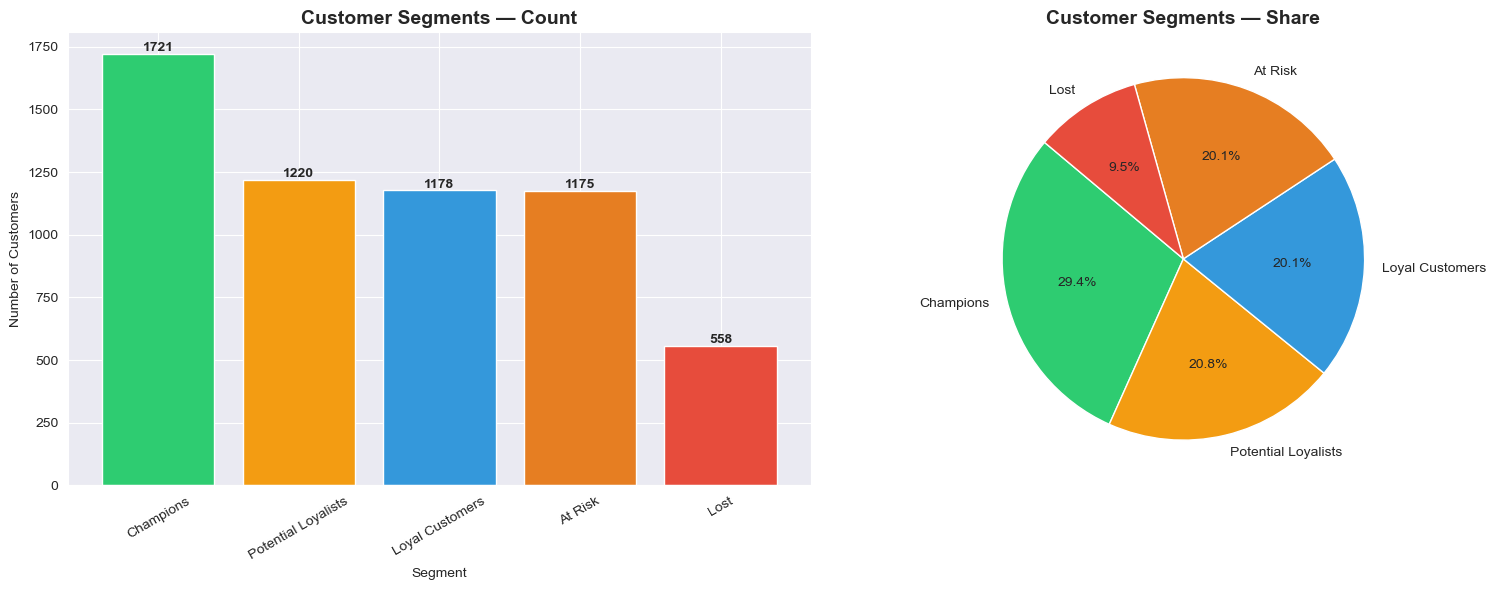

In [9]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'Potential Loyalists': '#f39c12',
    'At Risk': '#e67e22',
    'Lost': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bar_colors = [colors[s] for s in segment_counts['Segment']]
axes[0].bar(segment_counts['Segment'], segment_counts['Count'], color=bar_colors)
axes[0].set_title('Customer Segments — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

for i, (bar, val) in enumerate(zip(axes[0].patches, segment_counts['Count'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(segment_counts['Count'],
            labels=segment_counts['Segment'],
            colors=bar_colors,
            autopct='%1.1f%%',
            startangle=140)
axes[1].set_title('Customer Segments — Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/12_segments.png', dpi=150)
plt.show()

💰 Revenue by Segment:
            Segment    Monetary  Revenue_%
          Champions 13708112.47      80.31
    Loyal Customers  1908786.70      11.18
Potential Loyalists   946832.30       5.55
            At Risk   407390.50       2.39
               Lost    97446.00       0.57


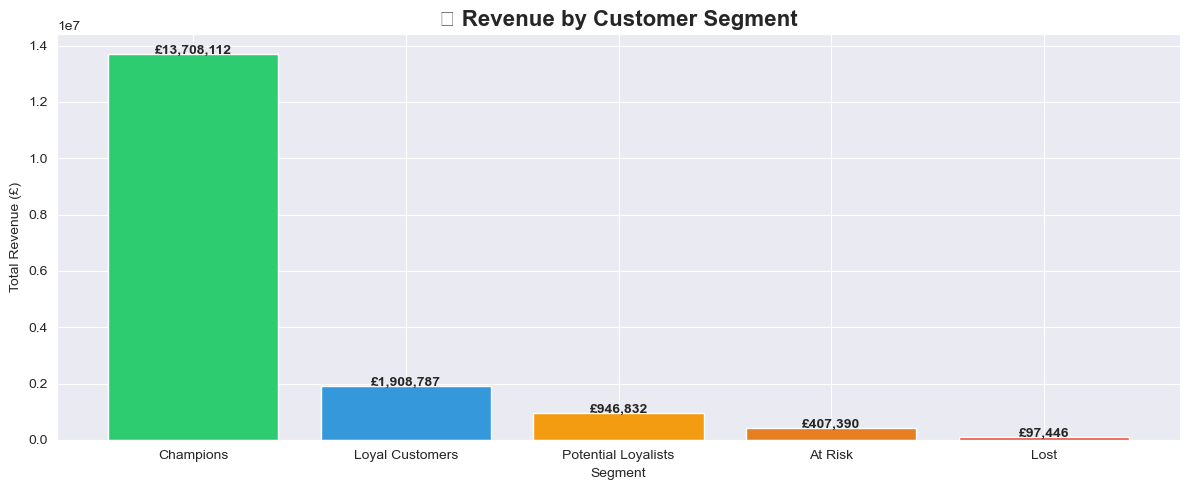

In [10]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values('Monetary', ascending=False)
segment_revenue['Revenue_%'] = (segment_revenue['Monetary'] / 
                                 segment_revenue['Monetary'].sum() * 100).round(2)

print("💰 Revenue by Segment:")
print(segment_revenue.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [colors[s] for s in segment_revenue['Segment']]
bars = ax.bar(segment_revenue['Segment'], segment_revenue['Monetary'], color=bar_colors)

for bar, val in zip(bars, segment_revenue['Monetary']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'£{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('💰 Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/13_segment_revenue.png', dpi=150)
plt.show()

In [11]:
segment_stats = rfm.groupby('Segment').agg(
    Total_Customers = ('Customer ID', 'count'),
    Avg_Recency     = ('Recency', 'mean'),
    Avg_Frequency   = ('Frequency', 'mean'),
    Avg_Monetary    = ('Monetary', 'mean'),
    Total_Revenue   = ('Monetary', 'sum')
).round(2).reset_index()

segment_stats = segment_stats.sort_values('Total_Revenue', ascending=False)
print("📊 Segment Stats:")
segment_stats

📊 Segment Stats:


,Segment,Total_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
1,Champions,1721,37.12,15.19,7965.20,13708112.47
3,Loyal Customers,1178,115.82,4.41,1620.36,1908786.70
4,Potential Loyalists,1220,212.31,2.53,776.09,946832.30
0,At Risk,1175,347.59,1.38,346.72,407390.50
2,Lost,558,544.45,1.00,174.63,97446.00


In [12]:
print("=" * 60)
print("📋 RFM BUSINESS RECOMMENDATIONS")
print("=" * 60)

for _, row in segment_stats.iterrows():
    seg = row['Segment']
    count = int(row['Total_Customers'])
    revenue = row['Total_Revenue']

    if seg == 'Champions':
        action = "Reward them. Give early access, loyalty rewards."
    elif seg == 'Loyal Customers':
        action = "Upsell higher value products. Send thank you offers."
    elif seg == 'Potential Loyalists':
        action = "Send targeted offers. Encourage repeat purchases."
    elif seg == 'At Risk':
        action = "Send win-back campaigns. Offer discounts urgently."
    else:
        action = "Send re-engagement emails. Last chance offers."

    print(f"\n🎯 {seg}")
    print(f"   Customers : {count}")
    print(f"   Revenue   : £{revenue:,.2f}")
    print(f"   Action    : {action}")

print("\n" + "=" * 60)

📋 RFM BUSINESS RECOMMENDATIONS

🎯 Champions
   Customers : 1721
   Revenue   : £13,708,112.47
   Action    : Reward them. Give early access, loyalty rewards.

🎯 Loyal Customers
   Customers : 1178
   Revenue   : £1,908,786.70
   Action    : Upsell higher value products. Send thank you offers.

🎯 Potential Loyalists
   Customers : 1220
   Revenue   : £946,832.30
   Action    : Send targeted offers. Encourage repeat purchases.

🎯 At Risk
   Customers : 1175
   Revenue   : £407,390.50
   Action    : Send win-back campaigns. Offer discounts urgently.

🎯 Lost
   Customers : 558
   Revenue   : £97,446.00
   Action    : Send re-engagement emails. Last chance offers.



In [13]:
rfm.to_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/rfm_segments.csv', index=False)
print("✅ RFM data saved!")
print("Final RFM shape:", rfm.shape)
print("\nColumns:", rfm.columns.tolist())

✅ RFM data saved!
Final RFM shape: (5852, 9)

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']
